In [27]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def get_historical_Data(tickers):
    data = pd.DataFrame()
    names = []
    
    for i in tickers:
        stock_data = yf.download(i, start="2018-03-03", end="2025-03-03")["Close"]
        data = pd.concat([data, stock_data], axis=1)
        names.append(i)
    
    data.columns = names
    return data

ticks = ["GOOGL", "AMZN", "V", "AZN", "PFE", "JPM", "NVDA", "PG", "AAPL", "BLK", "MSFT", "PLD", "XWD.TO", "NTR", "VTRS", "QQQ"]
d = get_historical_Data(ticks)
print(d.shape)
print(d.tail())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

(1792, 16)
                 GOOGL        AMZN           V        AZN    PFE         JPM  \
Date                                                                           
2025-02-24  179.250000  212.710007  349.859985  74.690002  26.65  261.339996   
2025-02-25  175.419998  212.800003  352.089996  75.400002  26.74  257.399994   
2025-02-26  172.729996  214.350006  350.630005  75.519997  26.42  258.790009   
2025-02-27  168.500000  208.740005  355.739990  75.650002  26.10  259.049988   
2025-02-28  170.279999  212.279999  362.709991  76.209999  26.43  264.649994   

                  NVDA          PG        AAPL         BLK        MSFT  \
Date                                                                     
2025-02-24  130.279999  170.539993  247.100006  952.799988  404.000000   
2025-02-25  126.629997  172.649994  247.039993  958.010010  397.899994   
2025-02-26  131.279999  171.300003  240.360001  953.770020  399.730011   
2025-02-27  120.150002  171.970001  237.300003  944.890015

In [22]:
dT = d.iloc[d.shape[0] - 252:,:]

d = d.iloc[:d.shape[0] - 252,:]

print("Testing Data dimension: ", dT.shape)
print("Training Data dimensions: ", d.shape)

Testing Data dimension:  (252, 16)
Training Data dimensions:  (1540, 16)


In [28]:
from scipy import stats
import numpy as np

expected_returns_a = d.pct_change()
expected_returns_a.columns = ticks
expected_returns_aA = pd.DataFrame(expected_returns_a.mean()*250)
expected_returns_aA = expected_returns_aA.T
dar = d.pct_change().iloc[1:,:]+1

gar = pd.DataFrame(np.prod(dar)**(1/float(6)) - 1)
full_return_annual = (pd.concat([expected_returns_aA.T, gar], axis = 1))

full_return_annual.columns = ["Average Arithmetic Returns", "Averaeg Geometric Returns"]
print("Expected Annual Returns ", expected_returns_aA)
print("dar", dar)
print("Full Annual Return", full_return_annual)

Expected Annual Returns        GOOGL      AMZN         V      AZN       PFE       JPM      NVDA  \
0  0.205293  0.200486  0.192223  0.16798  0.035625  0.186222  0.560462   

         PG      AAPL       BLK      MSFT       PLD    XWD.TO       NTR  \
0  0.153329  0.290922  0.148886  0.252497  0.165289  0.122798  0.093881   

      VTRS      QQQ  
0 -0.11683  0.18957  
dar                GOOGL      AMZN         V       AZN       PFE       JPM  \
Date                                                                     
2018-03-06  1.005609  1.009208  0.993272  0.996460  0.993355  1.000869   
2018-03-07  1.012844  1.004787  1.006526  0.997928  1.001394  0.996266   
2018-03-08  1.012861  1.004440  1.003037  1.002077  1.015864  1.000087   
2018-03-09  1.027856  1.017418  1.018737  1.000296  1.007397  1.028761   
2018-03-12  1.004385  1.012350  0.997831  1.001776  0.995649  0.996781   
...              ...       ...       ...       ...       ...       ...   
2025-02-24  0.997718  0.982131  1.0

/var/folders/ly/dwvwh7vx78722z89t2vvt04m0000gn/T/ipykernel_3298/3564859818.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  expected_returns_a = d.pct_change()
/var/folders/ly/dwvwh7vx78722z89t2vvt04m0000gn/T/ipykernel_3298/3564859818.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  dar = d.pct_change().iloc[1:,:]+1
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain th

In [29]:
portfolio_returns = []
portfolio_volatility = []
sharpe_ratio = []

stock_weights = []

num_assets = len(ticks)

num_portfolios = 1000000


daily_returns = d.pct_change()

annual_returns = (daily_returns.mean() * 250) + 1

cov_daily = daily_returns.cov()
cov_annual = cov_daily*250

print(annual_returns)

GOOGL     1.205293
AMZN      1.200486
V         1.192223
AZN       1.167980
PFE       1.035625
JPM       1.186222
NVDA      1.560462
PG        1.153329
AAPL      1.290922
BLK       1.148886
MSFT      1.252497
PLD       1.165289
XWD.TO    1.122798
NTR       1.093881
VTRS      0.883170
QQQ       1.189570
dtype: float64


/var/folders/ly/dwvwh7vx78722z89t2vvt04m0000gn/T/ipykernel_3298/3746365936.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = d.pct_change()


In [30]:
np.random.seed(3)

for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        returns = (np.dot(weights, (annual_returns)))
        volatility = np.sqrt(np.dot(weights.T, np.dot(cov_annual, weights)))
        
        sharpe = ((returns-1) / volatility)
        sharpe_ratio.append(sharpe)
        portfolio_returns.append(returns-1)
        portfolio_volatility.append(volatility)
        stock_weights.append(weights)

In [31]:
portfolio = {'Returns': portfolio_returns,
             'Volatility': portfolio_volatility,
             'Sharpe Ratio': sharpe_ratio}

for counter,symbol in enumerate(ticks):
    portfolio[symbol+' Weight'] = [Weight[counter] for Weight in stock_weights]
    
df = pd.DataFrame(portfolio)
df

,Returns,Volatility,Sharpe Ratio,GOOGL Weight,AMZN Weight,V Weight,AZN Weight,PFE Weight,JPM Weight,NVDA Weight,PG Weight,AAPL Weight,BLK Weight,MSFT Weight,PLD Weight,XWD.TO Weight,NTR Weight,VTRS Weight,QQQ Weight
0,0.135958,0.190104,0.715179,0.074872,0.096262,0.039544,0.069439,0.121382,0.121837,0.017071,0.028171,0.006996,0.059921,0.004061,0.062099,0.088241,0.037856,0.091926,0.080319
1,0.154662,0.208569,0.741540,0.003132,0.072984,0.033857,0.054211,0.037027,0.090521,0.057522,0.020486,0.071129,0.101906,0.040010,0.028987,0.050668,0.122288,0.127461,0.087811
2,0.161482,0.206178,0.783216,0.118155,0.110684,0.049468,0.012069,0.085512,0.073005,0.047318,0.029453,0.053202,0.061371,0.035235,0.038187,0.059898,0.112619,0.076723,0.037100
3,0.185154,0.209147,0.885281,0.037689,0.061640,0.027850,0.027304,0.069695,0.011827,0.065566,0.049105,0.095951,0.101247,0.093701,0.093442,0.050654,0.090588,0.046078,0.077662
4,0.207387,0.210408,0.985643,0.054252,0.074123,0.010245,0.040409,0.161786,0.038396,0.115141,0.108314,0.120547,0.079109,0.099354,0.011151,0.012083,0.033133,0.025287,0.016669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.159412,0.198115,0.804644,0.019155,0.076332,0.065250,0.101090,0.095429,0.036448,0.042438,0.010961,0.039942,0.113140,0.052874,0.082349,0.041517,0.081475,0.065329,0.076272
999996,0.203912,0.207183,0.984211,0.002183,0.075385,0.103877,0.076827,0.043415,0.016609,0.089688,0.100044,0.066051,0.102338,0.097456,0.043875,0.035754,0.057559,0.025244,0.063695
999997,0.186109,0.193879,0.959922,0.099622,0.007052,0.111527,0.062792,0.102271,0.010816,0.047390,0.107321,0.086684,0.005086,0.091918,0.088014,0.068602,0.011809,0.027633,0.071461
999998,0.197668,0.214707,0.920644,0.009821,0.040673,0.182710,0.022623,0.050647,0.055669,0.081049,0.053730,0.027418,0.159416,0.087430,0.070773,0.039730,0.026428,0.024546,0.067338


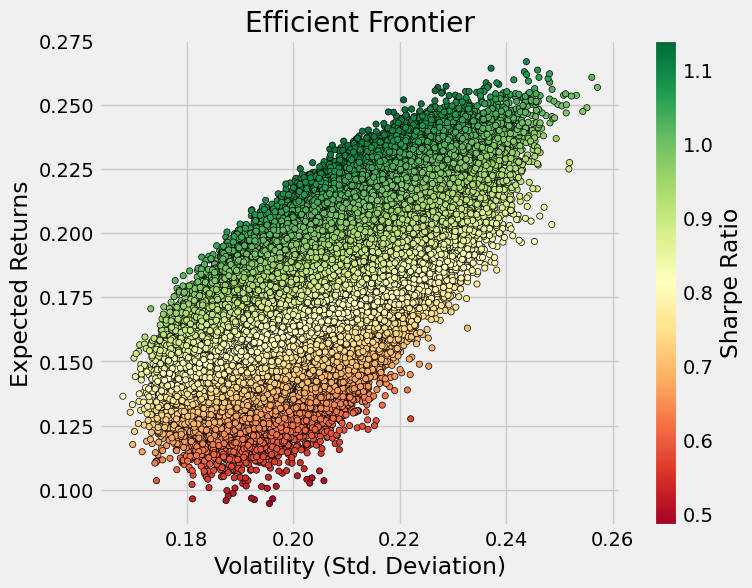

In [32]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
df.plot.scatter(x='Volatility', y='Returns', c='Sharpe Ratio',
                cmap='RdYlGn', edgecolors='black', figsize=(7.5,6), grid=True)
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Returns')
plt.title('Efficient Frontier')
plt.show()

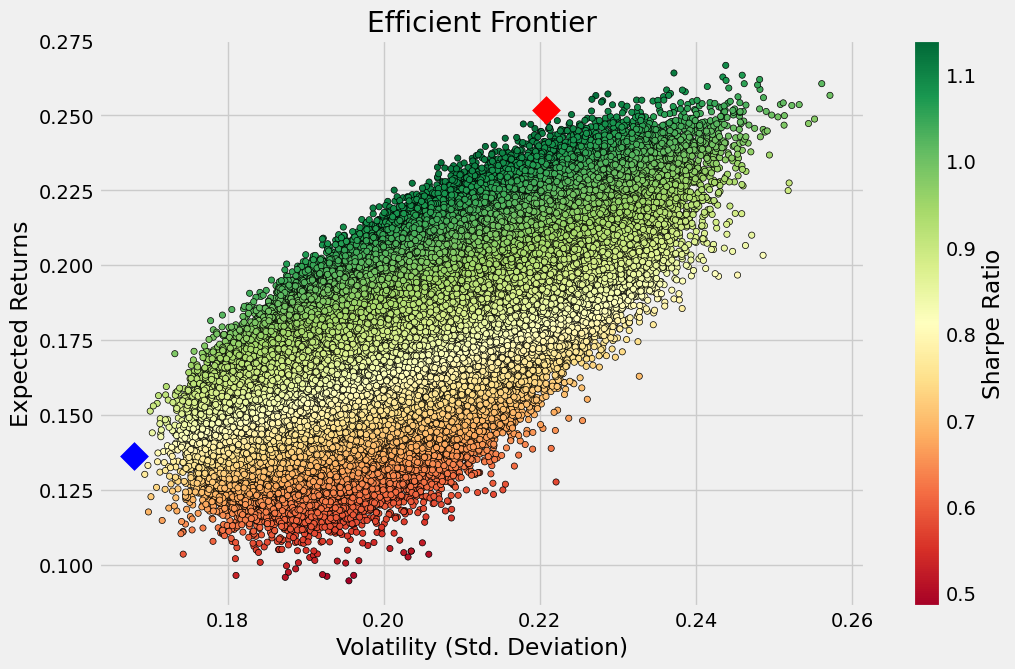

In [36]:
min_volatility = df['Volatility'].min()
max_sharpe = df['Sharpe Ratio'].max()

sharpe_portfolio = df.loc[df['Sharpe Ratio'] == max_sharpe]
min_variance_port = df.loc[df['Volatility'] == min_volatility]

plt.style.use('fivethirtyeight')
df.plot.scatter(x='Volatility', y='Returns', c='Sharpe Ratio',
                cmap='RdYlGn', edgecolors='black', figsize=(11, 7), grid=True)
plt.scatter(x=sharpe_portfolio['Volatility'], y=sharpe_portfolio['Returns'], c='red', marker='D', s=200)
plt.scatter(x=min_variance_port['Volatility'], y=min_variance_port['Returns'], c='blue', marker='D', s=200)
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Returns')
plt.title('Efficient Frontier')
plt.show()

In [34]:
r_ef = pd.concat([min_variance_port.T,sharpe_portfolio.T], axis = 1)
r_ef.columns = ["Minimum Risk Adjusted Values", "Maximum Risk Adjusted Values"]
print(r_ef) 

               Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
Returns                            0.136452                      0.251829
Volatility                         0.168012                      0.220737
Sharpe Ratio                       0.812159                      1.140855
GOOGL Weight                       0.013407                      0.001000
AMZN Weight                        0.044250                      0.010649
V Weight                           0.026085                      0.027692
AZN Weight                         0.144158                      0.125665
PFE Weight                         0.123289                      0.086489
JPM Weight                         0.069480                      0.063081
NVDA Weight                        0.004173                      0.198366
PG Weight                          0.143580                      0.133124
AAPL Weight                        0.036633                      0.127861
BLK Weight                         0.0

In [35]:
amount_invest = 1000
expected_return = pd.DataFrame(amount_invest * (1+r_ef.iloc[0,:]))
print("----------------------------------------------------------------")
print("                Expected Returns on my Portfolio")
print("----------------------------------------------------------------")
print(expected_return.T)
print("")
print("----------------------------------------------------------------")
print("If I invested", amount_invest,"USD on |", dT.index[0],"| I would have...")
actual_return = (dT.iloc[dT.shape[0]-1,:] - dT.iloc[0,:]) / ( dT.iloc[0,:])
# Multipling the weights to the price at the beginning of the year
beg_price = (dT.iloc[0,:])
end_price = dT.iloc[dT.shape[0]-1,:]
print("----------------------------------------------------------------")
# Weights derived from the Efficient Frontier Portfolio
# Weights for Minimum Risk
w = np.array(r_ef.iloc[3:,0])

percentage_change = (end_price - beg_price)/(beg_price)+1
print("Using the Portfolio Weights for Minimum Risk Return Portfolio")
money_left = sum(w * percentage_change* amount_invest)
print("")
print("    Starting balance $ 1000 : Ending with $ ",round(money_left, 2))
print("")
print("----------------------------------------------------------------")
print("Using the Portfolio Weights Maximized Risk-Return Portfolio")
# Weights for Maxmimum Risk
w1 = np.array(r_ef.iloc[3:,1])

money_left1 = sum(w1 * percentage_change* amount_invest)
print("")
print("    Starting balance $ 1000 : Ending with $ ", round(money_left1,2))
print("")

----------------------------------------------------------------
                Expected Returns on my Portfolio
----------------------------------------------------------------
         Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
Returns                   1136.452351                   1251.828694

----------------------------------------------------------------
If I invested 1000 USD on | 2024-03-07 00:00:00 | I would have...
----------------------------------------------------------------
Using the Portfolio Weights for Minimum Risk Return Portfolio

    Starting balance $ 1000 : Ending with $  1149.69

----------------------------------------------------------------
Using the Portfolio Weights Maximized Risk-Return Portfolio

    Starting balance $ 1000 : Ending with $  1211.47

